(mmm_funnel_from_yml)=
# Building funnel-aware MMMs from YAML

Media mix models often include both upper-funnel spend (TV, social) and lower-funnel activity (search, retargeting). A **flat** YAML spec puts every column in `channel_columns` and implies direct effects on the target. A **funnel** spec adds an unobserved demand hub, measurement links, and mediated paths through custom `effects:`.

If you have not used the YAML builder before, start with {ref}`mmm_build_from_yml_example`. That notebook shows the stock `MMM` path: `channel_columns`, adstock, saturation, and `build_mmm_from_yaml` with a tabular `X`. **This notebook extends that workflow** when the causal graph is not flat — custom `MuEffect` subclasses, `effects:` in YAML, and `extra_vars` for columns that are not channels or controls but must reach the model graph (for example mediator indicators).

This notebook shows how those two worlds look side by side when you build models with `build_mmm_from_yaml`. It mirrors the hand-wired specs in {ref}`mmm_funnel_mueffect` (national) and {ref}`mmm_funnel_mueffect_advanced` (geo panel).

Every funnel example follows the same four-step loop:

1. **Causal DAG** — the claims the specification makes about the world (hand-drawn for now; see issue #2886)
2. **Effect class** — the `MuEffect` subclass that builds that subgraph (defined beside the notebook, not in the library yet)
3. **YAML** — the configuration file referencing the class through `REGISTRY`
4. **PyMC graph** — the computational graph `build_mmm_from_yaml` produces

We show **one naive baseline**, then two funnel topologies. Placeholder `X` / `y` supply the right columns and dimensions; nothing is fit here.

```{important}
`MeasuredMediatorEffect` and `BudgetDualIndicatorEffect` are **notebook-local** names for specific subgraph topologies — not general funnel builders. The YAML specs (`funnel_intro.yml`, `funnel_advanced.yml`) register those classes on `REGISTRY` for this demo only; that is not a supported public API.
```

```{note}
**Reading the causal DAGs.** Grey-filled nodes are observed. Dashed-outline nodes are unobserved (deterministic hubs, not stochastic latents). Dashed or dotted edges mark measurement or indicator links.
```

```{note}
Use the Jupyter kernel **pymc-marketing (funnel-yaml worktree)** — this branch adds YAML `extra_vars` support.
```


In [ ]:
import sys
import warnings
from pathlib import Path

import graphviz as gr
import numpy as np
import pandas as pd
import pymc.dims as pmd
from IPython.display import Markdown, display
from pydantic import InstanceOf
from pyprojroot import here

import pymc_marketing
from pymc_marketing.mmm import AdstockTransformation, SaturationTransformation
from pymc_marketing.mmm.additive_effect import DataVarMuEffect, IncrementalitySpec
from pymc_marketing.mmm.builders.factories import REGISTRY
from pymc_marketing.mmm.builders.schema import MMMYamlConfig
from pymc_marketing.mmm.builders.yaml import build_mmm_from_yaml
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.paths import data_dir

WORKTREE_PYTHON = here() / ".venv" / "bin" / "python"
if "extra_vars" not in MMMYamlConfig.model_fields:
    raise ImportError(
        "This notebook requires pymc-marketing from the funnel-from-yaml branch "
        "(YAML `extra_vars` support).\n\n"
        f"  Python: {sys.executable}\n"
        f"  pymc_marketing: {pymc_marketing.__file__}\n\n"
        "Select the Jupyter kernel **pymc-marketing (funnel-yaml worktree)** "
        f"(interpreter: {WORKTREE_PYTHON}), then restart the kernel."
    )

warnings.filterwarnings("ignore")

CONFIG_DIR = data_dir / "config_files"
NOTEBOOK_DIR = here() / "docs" / "source" / "notebooks" / "mmm"

%config InlineBackend.figure_format = "retina"

n_dates = 10
dates = pd.date_range("2021-01-04", periods=n_dates, freq="W-MON")
X_intro = pd.DataFrame(
    {
        "date": dates,
        "upper_spend": np.ones(n_dates),
        "lower_spend": np.ones(n_dates),
    }
)
y_intro = np.ones(n_dates)

# Funnel columns promoted via `extra_vars` in funnel_intro.yml (not channel_columns).
X_funnel_intro = X_intro.assign(lower_control=np.ones(n_dates))

In [3]:
def show_yaml(path: Path) -> None:
    """Print a YAML config so readers can follow along in the notebook."""
    text = path.read_text()
    display(Markdown(f"**`{path.name}`**\n\n```yaml\n{text}```"))


def show_graph(mmm, title: str | None = None) -> None:
    """Display the PyMC graph built from a YAML spec."""
    if title:
        display(Markdown(f"**{title}** — PyMC graph"))
    display(mmm.graphviz())


def _node_attrs(kind: str) -> dict:
    if kind == "observed":
        return {"style": "filled", "fillcolor": "lightgray", "shape": "ellipse"}
    if kind == "latent":
        return {"style": "dashed", "shape": "ellipse"}
    raise ValueError(kind)


def draw_causal_dag(
    nodes: list[tuple[str, str, str]],
    edges: list,
    *,
    title: str | None = None,
    rankdir: str = "LR",
) -> gr.Digraph:
    """Hand-drawn causal DAG. kind is 'observed' or 'latent'."""
    g = gr.Digraph()
    g.attr(rankdir=rankdir)
    if title:
        g.attr(label=title, labelloc="t", fontsize="14")
    for node_id, label, kind in nodes:
        g.node(node_id, label, **_node_attrs(kind))
    for edge in edges:
        if len(edge) == 2:
            g.edge(edge[0], edge[1])
        else:
            g.edge(edge[0], edge[1], **edge[2])
    return g


def show_causal_dag(*args, **kwargs) -> None:
    display(draw_causal_dag(*args, **kwargs))

## Naive baseline — everything is a direct channel

The simplest YAML pattern lists every spend column under `channel_columns`. That is easy to write, but the implied causal graph is flat: each channel points straight at the target with no mediation.

We keep **one** such example here as a contrast point. The funnel sections below need custom effect classes because this baseline cannot express their structure.


### Causal DAG

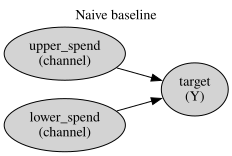

In [4]:
show_causal_dag(
    [
        ("U", "upper_spend\n(channel)", "observed"),
        ("M", "lower_spend\n(channel)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [("U", "Y"), ("M", "Y")],
    title="Naive baseline",
)

### YAML

In [5]:
show_yaml(CONFIG_DIR / "funnel_intro_naive_a.yml")

**`funnel_intro_naive_a.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y_obs
    channel_columns: [upper_spend, lower_spend]
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs: {l_max: 8}
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs: {}
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

### PyMC graph

**Naive baseline** — PyMC graph

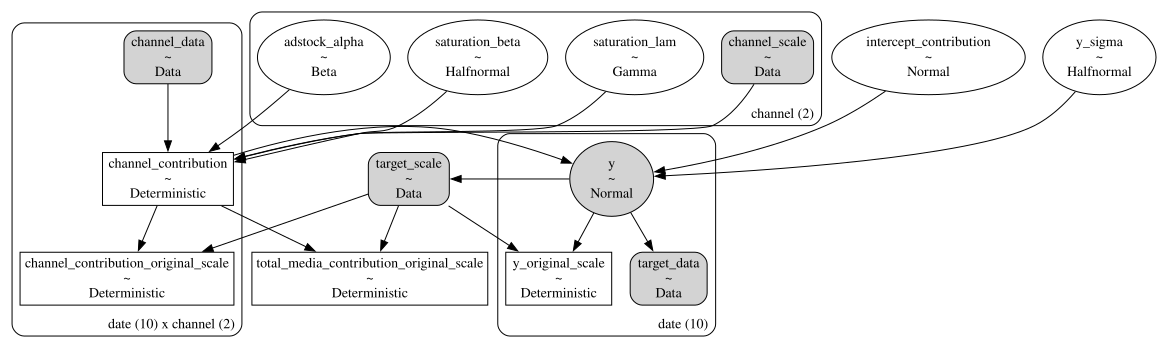

In [6]:
m_naive = build_mmm_from_yaml(
    CONFIG_DIR / "funnel_intro_naive_a.yml", X=X_intro, y=y_intro
)
show_graph(m_naive, "Naive baseline")

## Part 1 — National funnel

{ref}`mmm_funnel_mueffect` encodes upper spend driving an **unobserved demand hub**, with observed lower spend as a noisy proxy. The target receives both a direct upper-funnel path (base `MMM`) and an indirect path through demand (`MeasuredMediatorEffect`).

### Causal DAG


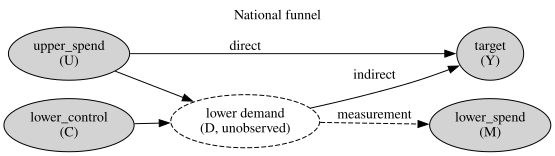

In [7]:
show_causal_dag(
    [
        ("U", "upper_spend\n(U)", "observed"),
        ("C", "lower_control\n(C)", "observed"),
        ("D", "lower demand\n(D, unobserved)", "latent"),
        ("M", "lower_spend\n(M)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("U", "Y", {"label": "direct"}),
        ("U", "D"),
        ("C", "D"),
        ("D", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "Y", {"label": "indirect"}),
    ],
    title="National funnel",
)

### Effect class

`MeasuredMediatorEffect` is the class we need to build this structure: one unobserved mediator (**D**), one measurement (**D → M**), and a mediated contribution into `μ` (**D → Y**). Direct **U → Y** paths stay in base `MMM` via `channel_columns`.

YAML kwargs name **subgraph roles**, not funnel jargon:

| Kwarg | Subgraph edge |
|-------|----------------|
| `hub_adstock`, `hub_saturation` | parent **U → D** |
| `contribution_adstock`, `contribution_saturation` | **D → μ** |


In [8]:
class MeasuredMediatorEffect(DataVarMuEffect):
    """Unobserved mediator hub with one measured indicator and a mediated mu contribution."""

    data_vars: list[str] = ["lower_spend", "lower_control"]
    prefix: str = "mediator"
    hub_adstock: InstanceOf[AdstockTransformation]
    hub_saturation: InstanceOf[SaturationTransformation]
    contribution_adstock: InstanceOf[AdstockTransformation]
    contribution_saturation: InstanceOf[SaturationTransformation]

    def to_dict(self) -> dict:
        """Serialize effect configuration."""
        return {
            "prefix": self.prefix,
            "data_vars": list(self.data_vars),
            "hub_adstock": self.hub_adstock.to_dict(),
            "hub_saturation": self.hub_saturation.to_dict(),
            "contribution_adstock": self.contribution_adstock.to_dict(),
            "contribution_saturation": self.contribution_saturation.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Return incrementality settings."""
        return IncrementalitySpec()

    def create_effect(self, mmm):
        """Build the measured-mediator subgraph from the national funnel DAG."""
        model = mmm.model
        parent_into_hub = self.hub_saturation.apply(
            self.hub_adstock.apply(
                mmm.channel_data_scaled.isel(channel=0), core_dim="date"
            ),
            core_dim="date",
        )
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0)
        parent_coef = pmd.HalfNormal(f"{self.prefix}_parent_coef", sigma=1.0)
        hub = pmd.Deterministic(
            f"{self.prefix}_hub",
            baseline + parent_coef * model["lower_control"] + parent_into_hub,
        )
        pmd.TruncatedNormal(
            f"{self.prefix}_measurement",
            mu=hub,
            sigma=pmd.HalfNormal(f"{self.prefix}_measurement_sigma", sigma=1.0),
            lower=0.0,
            observed=model["lower_spend"],
        )
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.contribution_saturation.apply(
                self.contribution_adstock.apply(hub, core_dim="date"),
                core_dim="date",
            ),
        )


REGISTRY["MeasuredMediatorEffect"] = MeasuredMediatorEffect

### YAML

`extra_vars` lists columns that are not channels or controls but must appear in the xarray Dataset for `MeasuredMediatorEffect` (`lower_spend`, `lower_control`).

In [9]:
show_yaml(NOTEBOOK_DIR / "funnel_intro.yml")

**`funnel_intro.yml`**

```yaml
# Requires MeasuredMediatorEffect defined in mmm_funnel_from_yml.ipynb (registered on REGISTRY).
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y_obs
    channel_columns: [upper_spend]
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs: {l_max: 8}
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs: {}
    sampler_config:
      nuts_sampler: nutpie

extra_vars: [lower_spend, lower_control]

effects:
  - class: MeasuredMediatorEffect
    kwargs:
      hub_adstock:
        class: pymc_marketing.mmm.GeometricAdstock
        kwargs: {l_max: 8, prefix: adstock_hub}
      hub_saturation:
        class: pymc_marketing.mmm.LogisticSaturation
        kwargs: {prefix: sat_hub}
      contribution_adstock:
        class: pymc_marketing.mmm.GeometricAdstock
        kwargs: {l_max: 8, prefix: adstock_contribution}
      contribution_saturation:
        class: pymc_marketing.mmm.LogisticSaturation
        kwargs: {prefix: sat_contribution}

original_scale_vars: [channel_contribution, mediator_effect_contribution, y]
```

### PyMC graph

**National funnel** — PyMC graph

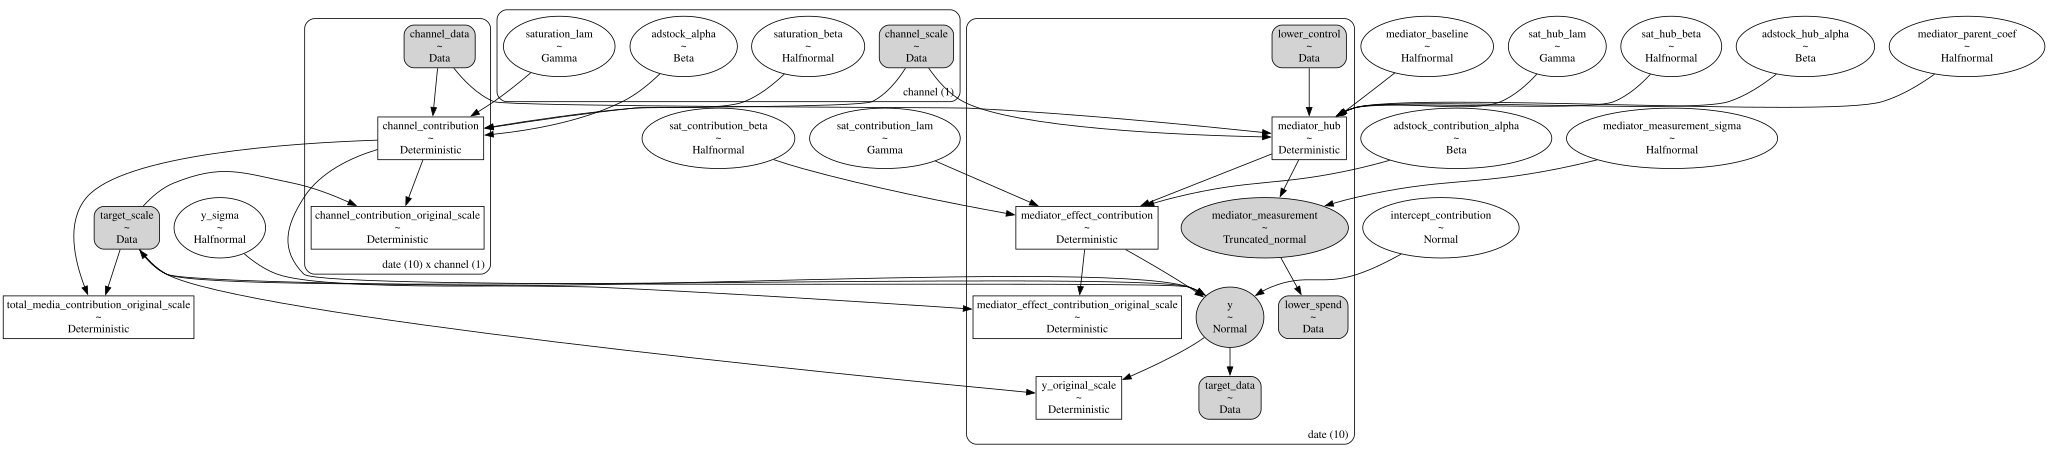

In [10]:
m_funnel = build_mmm_from_yaml(
    NOTEBOOK_DIR / "funnel_intro.yml", X=X_funnel_intro, y=y_intro
)
show_graph(m_funnel, "National funnel")

## Part 2 — Geo panel funnel

The advanced topology from {ref}`mmm_funnel_mueffect_advanced` is **not** the national graph with a `geo` dimension bolted on. It adds category demand, a budget-linked structural spend node, **two** indicator likelihoods, and routes the mediated contribution through that spend node rather than through demand directly.

### Causal DAG


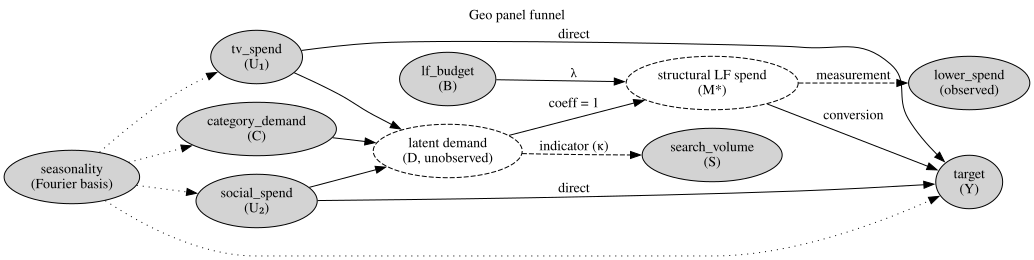

In [11]:
show_causal_dag(
    [
        ("season", "seasonality\n(Fourier basis)", "observed"),
        ("U1", "tv_spend\n(U₁)", "observed"),
        ("U2", "social_spend\n(U₂)", "observed"),
        ("C", "category_demand\n(C)", "observed"),
        ("B", "lf_budget\n(B)", "observed"),
        ("D", "latent demand\n(D, unobserved)", "latent"),
        ("MS", "structural LF spend\n(M*)", "latent"),
        ("M", "lower_spend\n(observed)", "observed"),
        ("S", "search_volume\n(S)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("season", "U1", {"style": "dotted"}),
        ("season", "U2", {"style": "dotted"}),
        ("season", "C", {"style": "dotted"}),
        ("season", "Y", {"style": "dotted"}),
        ("U1", "Y", {"label": "direct"}),
        ("U2", "Y", {"label": "direct"}),
        ("U1", "D"),
        ("U2", "D"),
        ("C", "D"),
        ("D", "MS", {"label": "coeff = 1"}),
        ("B", "MS", {"label": "λ"}),
        ("MS", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "S", {"label": "indicator (κ)", "style": "dashed"}),
        ("MS", "Y", {"label": "conversion"}),
    ],
    title="Geo panel funnel",
)

Placeholder panel data with geo, channel, and lower-funnel columns referenced by `extra_vars`.

In [12]:
geos = ["north", "south", "west"]
channels = ["tv_spend", "social_spend"]
dates_adv = pd.date_range("2021-01-04", periods=n_dates, freq="W-MON")
rows = [
    {
        "date": date,
        "geo": geo,
        "tv_spend": 1.0,
        "social_spend": 1.0,
        "category_demand": 1.0,
        "t": 0.5,
        "lower_spend": 1.0,
        "search_volume": 1.0,
        "lf_budget": 1.0,
    }
    for date in dates_adv
    for geo in geos
]
df_adv = pd.DataFrame(rows)
y_adv = np.ones(len(df_adv))

### Effect class

`BudgetDualIndicatorEffect` matches this **different** subgraph: the hub feeds structural spend through a budget term, lower spend measures that spend node (not the hub), search volume is a second indicator on the hub, and the mediated contribution routes through spend.

| Kwarg | Subgraph edge |
|-------|----------------|
| `hub_input_transform` | channel parents **→ D** |
| `contribution_transform` | structural spend **→ μ** |


In [13]:
class BudgetDualIndicatorEffect(DataVarMuEffect):
    """Demand hub, budget-linked structural spend, two indicators, mediated mu contribution."""

    hub_input_transform: InstanceOf[MediaTransformation]
    contribution_transform: InstanceOf[MediaTransformation]

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize effect configuration."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "hub_input_transform": self.hub_input_transform.to_dict(),
            "contribution_transform": self.contribution_transform.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Return incrementality settings."""
        return IncrementalitySpec(
            additional_carryover_lags=self.contribution_transform.adstock.l_max
        )

    def create_effect(self, mmm):
        """Build the budget-linked dual-indicator subgraph from the geo funnel DAG."""
        model = mmm.model
        parents_into_hub = self.hub_input_transform(
            mmm.channel_data_scaled, dim="date"
        ).sum(dim="channel")
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0, dims=("geo",))
        parent_coef = pmd.HalfNormal(
            f"{self.prefix}_parent_coef", sigma=1.0, dims=("geo",)
        )
        hub = pmd.Deterministic(
            f"{self.prefix}_hub",
            baseline + parent_coef * model["category_demand"] + parents_into_hub,
        )
        budget_coef = pmd.HalfNormal(
            f"{self.prefix}_budget_coef", sigma=0.5, dims=("geo",)
        )
        spend = pmd.Deterministic(
            f"{self.prefix}_spend",
            hub + budget_coef * model["lf_budget"],
        )
        pmd.TruncatedNormal(
            f"{self.prefix}_spend_measurement",
            mu=spend,
            sigma=pmd.HalfNormal(
                f"{self.prefix}_spend_measurement_sigma", sigma=1.0, dims=("geo",)
            ),
            lower=0.0,
            observed=model["lower_spend"],
        )
        indicator_coef = pmd.HalfNormal(f"{self.prefix}_indicator_coef", sigma=1.0)
        pmd.Normal(
            f"{self.prefix}_hub_indicator",
            mu=indicator_coef * hub,
            sigma=pmd.HalfNormal(
                f"{self.prefix}_hub_indicator_sigma", sigma=1.0, dims=("geo",)
            ),
            observed=model["search_volume"],
        )
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.contribution_transform(spend, dim="date"),
        )


REGISTRY["BudgetDualIndicatorEffect"] = BudgetDualIndicatorEffect

### YAML

Same pattern: `extra_vars` carries lower-funnel and structural columns that `BudgetDualIndicatorEffect` reads from the Dataset.

In [14]:
show_yaml(NOTEBOOK_DIR / "funnel_advanced.yml")

**`funnel_advanced.yml`**

```yaml
# Requires BudgetDualIndicatorEffect defined in mmm_funnel_from_yml.ipynb (registered on REGISTRY).
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

extra_vars: [lower_spend, search_volume, category_demand, lf_budget]

effects:
  - class: BudgetDualIndicatorEffect
    kwargs:
      data_vars: [lower_spend, search_volume, category_demand, lf_budget]
      prefix: budget_dual
      hub_input_transform:
        class: pymc_marketing.mmm.media_transformation.MediaTransformation
        kwargs:
          adstock_first: true
          dims: [geo, channel]
          adstock:
            class: pymc_marketing.mmm.GeometricAdstock
            kwargs:
              l_max: 8
              prefix: adstock_hub_input
              priors:
                alpha:
                  distribution: Beta
                  alpha: 2
                  beta: 3
                  dims: channel
          saturation:
            class: pymc_marketing.mmm.LogisticSaturation
            kwargs:
              prefix: sat_hub_input
              priors:
                lam:
                  distribution: Gamma
                  mu: 2.0
                  sigma: 1.0
                  dims: channel
                beta:
                  distribution: HalfNormal
                  sigma: 1.0
                  dims: [geo, channel]
      contribution_transform:
        class: pymc_marketing.mmm.media_transformation.MediaTransformation
        kwargs:
          adstock_first: true
          dims: [geo]
          adstock:
            class: pymc_marketing.mmm.GeometricAdstock
            kwargs:
              l_max: 8
              prefix: adstock_contribution
              priors:
                alpha:
                  distribution: Beta
                  alpha: 2
                  beta: 3
                  dims: geo
          saturation:
            class: pymc_marketing.mmm.LogisticSaturation
            kwargs:
              prefix: sat_contribution
              priors:
                lam:
                  distribution: Gamma
                  mu: 1.5
                  sigma: 0.5
                beta:
                  distribution: HalfNormal
                  sigma: 1.0
                  dims: geo

original_scale_vars: [channel_contribution, budget_dual_effect_contribution, y]
```

### PyMC graph

**Geo panel funnel** — PyMC graph

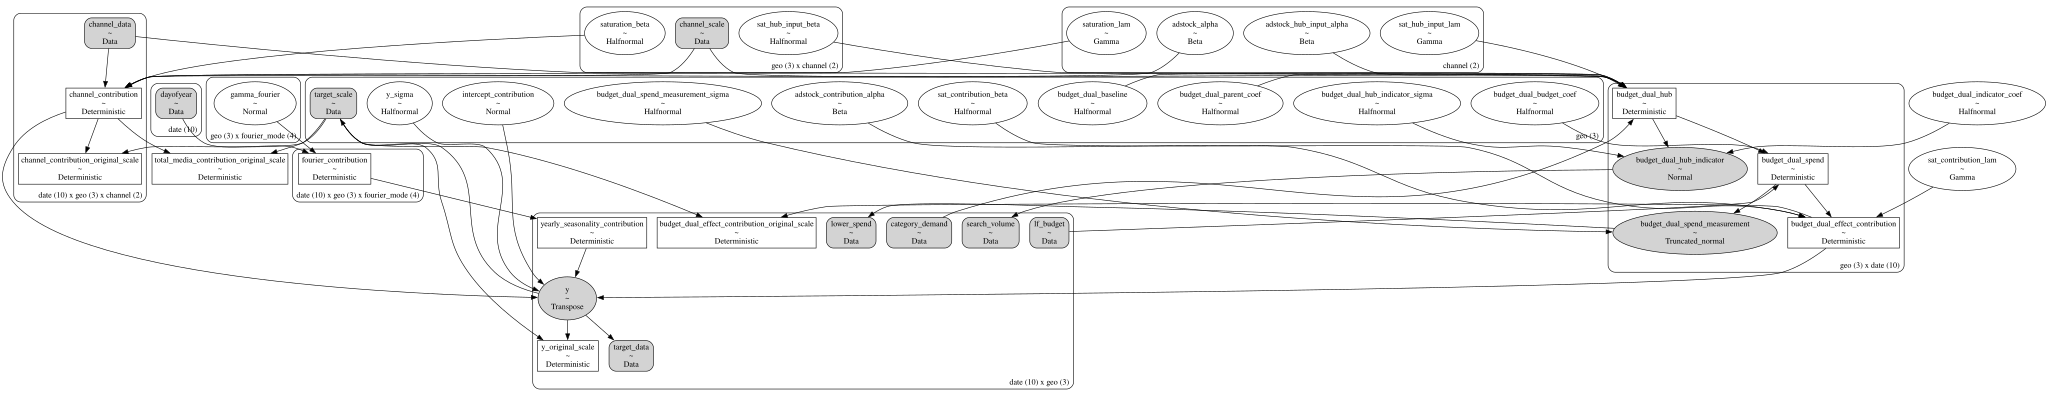

In [15]:
m_adv_funnel = build_mmm_from_yaml(
    NOTEBOOK_DIR / "funnel_advanced.yml", X=df_adv, y=y_adv
)
show_graph(m_adv_funnel, "Geo panel funnel")

## Summary

- A flat YAML spec (`channel_columns` only) implies a direct-effects DAG — useful as a baseline, but it cannot represent mediated funnel structure.
- Funnel specs extend the builder with `effects:` and `extra_vars`. Class names (`MeasuredMediatorEffect`, `BudgetDualIndicatorEffect`) describe **subgraph topology**; “funnel” remains the **use case** in DAGs and narrative.
- The repeatable loop is **causal DAG → effect class → YAML → PyMC graph**. Fitting, priors, and ROAS interpretation stay in {ref}`mmm_funnel_mueffect` and {ref}`mmm_funnel_mueffect_advanced`.

```{tip}
In your own domain: which spend columns are true channels versus noisy proxies for unobserved demand? That distinction is exactly what these effect classes encode — and why one misnamed “FunnelEffect” was never going to cover every DAG.
```


In [16]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Tue, 18 Aug 2026

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.15.0

pymc_marketing: 1.0.0
pytensor      : 3.0.7

IPython       : 9.15.0
graphviz      : 0.21
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.0.1
pymc_marketing: 1.0.0
pyprojroot    : 0.3.0

Watermark: 2.6.0

